After the preprocessing and choosing the model we will start with the training
---



In [55]:
!pip install xgboost


[notice] A new release of pip is available: 24.3.1 -> 26.1.2
[notice] To update, run: pip install --upgrade pip


In [56]:
!pip install scikit-learn


[notice] A new release of pip is available: 24.3.1 -> 26.1.2
[notice] To update, run: pip install --upgrade pip


In [57]:
import pandas as pd


In [58]:
# Train Dataset
df_train = pd.read_parquet('../data/train.parquet')
X_train = df_train.drop(columns=['isFraud'])
y_train = df_train['isFraud']

In [59]:
# Validation Dataset
df_val = pd.read_parquet('../data/validation.parquet')
X_val = df_val.drop(columns=['isFraud'])
y_val = df_val['isFraud']

In [60]:
# Test Dataset
df_test = pd.read_parquet('../data/test.parquet')
X_test = df_test.drop(columns=['isFraud'])
y_test = df_test['isFraud']

In [61]:
from xgboost import XGBClassifier

model = XGBClassifier(random_state=42)
model.fit(X_train, y_train)

,"base_score base_score: float | typing.List[float] | NoneThe initial prediction score of all instances, global bias.",None
,booster,None
,"callbacks callbacks: typing.List[xgboost.callback.TrainingCallback] | NoneList of callback functions that are applied at end of each iteration.It is possible to use predefined callbacks by using:ref:`Callback API <callback_api>`... note:: States in callback are not preserved during training, which means callback objects can not be reused for multiple training sessions without reinitialization or deepcopy... code-block:: python for params in parameters_grid: # be sure to (re)initialize the callbacks before each run callbacks = [xgb.callback.LearningRateScheduler(custom_rates)] reg = xgboost.XGBRegressor(**params, callbacks=callbacks) reg.fit(X, y)",None
,colsample_bylevel colsample_bylevel: float | NoneSubsample ratio of columns for each level.,None
,colsample_bynode colsample_bynode: float | NoneSubsample ratio of columns for each split.,None
,colsample_bytree colsample_bytree: float | NoneSubsample ratio of columns when constructing each tree.,None
,"device device: str | None.. versionadded:: 2.0.0Device ordinal, available options are `cpu`, `cuda`, and `gpu`.",None
,"early_stopping_rounds early_stopping_rounds: int | None.. versionadded:: 1.6.0- Activates early stopping. Validation metric needs to improve at least once in every **early_stopping_rounds** round(s) to continue training. Requires at least one item in **eval_set** in :py:meth:`fit`.- If early stopping occurs, the model will have two additional attributes: :py:attr:`best_score` and :py:attr:`best_iteration`. These are used by the :py:meth:`predict` and :py:meth:`apply` methods to determine the optimal number of trees during inference. If users want to access the full model (including trees built after early stopping), they can specify the `iteration_range` in these inference methods. In addition, other utilities like model plotting can also use the entire model.- If you prefer to discard the trees after `best_iteration`, consider using the callback function :py:class:`xgboost.callback.EarlyStopping`.- If there's more than one item in **eval_set**, the last entry will be used for early stopping. If there's more than one metric in **eval_metric**, the last metric will be used for early stopping.",None
,enable_categorical enable_categorical: boolSee the same parameter of :py:class:`DMatrix` for details.,True
,"eval_metric eval_metric: str | typing.List[str | typing.Callable] | typing.Callable | None.. versionadded:: 1.6.0Metric used for monitoring the training result and early stopping. It can be astring or list of strings as names of predefined metric in XGBoost (See:doc:`/parameter`), one of the metrics in :py:mod:`sklearn.metrics`, or anyother user defined metric that looks like `sklearn.metrics`.If custom objective is also provided, then custom metric should implement thecorresponding reverse link function.Unlike the `scoring` parameter commonly used in scikit-learn, when a callableobject is provided, it's assumed to be a cost function and by default XGBoostwill minimize the result during early stopping.For advanced usage on Early stopping like directly choosing to maximize insteadof minimize, see :py:obj:`xgboost.callback.EarlyStopping`.See :doc:`/tutorials/custom_metric_obj` and :ref:`custom-obj-metric` for moreinformation... code-block:: python from sklearn.datasets import load_diabetes from sklearn.metrics import mean_absolute_error X, y = load_diabetes(return_X_y=True) reg = xgb.XGBRegressor( tree_method=""hist"", eval_metric=mean_absolute_error, ) reg.fit(X, y, eval_set=[(X, y)])",None
,feature_types feature_types: typing.Sequence[str] | None.. versionadded:: 1.7.0Used for specifying feature types without constructing a dataframe. Seethe :py:class:`DMatrix` for details.,None


In [62]:
from sklearn.metrics import classification_report, roc_auc_score

y_pred = model.predict(X_val)
y_pred_proba = model.predict_proba(X_val)[:, 1]

print(classification_report(y_val, y_pred))
print(f"ROC-AUC: {roc_auc_score(y_val, y_pred_proba):.4f}")

              precision    recall  f1-score   support

           0       0.98      1.00      0.99    113497
           1       0.77      0.38      0.51      4611

    accuracy                           0.97    118108
   macro avg       0.87      0.69      0.75    118108
weighted avg       0.97      0.97      0.97    118108

ROC-AUC: 0.8973


In [63]:
y_train.value_counts(dropna=False)

isFraud
0    342336
1     11988
Name: count, dtype: int64

## First training iteration analysis

### ROC-AUC 0.91
The model has strong discriminative power: it correctly ranks 91% of fraud/non-fraud pairs. This is the most honest metric here because it evaluates the model across all thresholds, not just the default 0.5.

### Recall 0.39 on fraud
The model only catches 39% of actual fraud cases. In production that means 6 out of 10 fraudulent transactions pass through undetected. For a regulated financial environment, this is the critical number to improve.

### Why the gap between ROC-AUC and recall?
  Two reasons:
  1. Default threshold — XGBoost predicts a probability and flags fraud if it's above 0.5. But with imbalanced data, the model is conservative. Lowering the threshold (e.g. to 0.3) would push recall up at the cost of some precision.
  2. Class imbalance — 342k non-fraud vs 12k fraud. The model learned mostly from non-fraud examples. XGBoost has a scale_pos_weight parameter for this: setting it to ~28.6 (ratio of negatives to positives) tells the model to penalise missing fraud more.
  Accuracy is misleading here
  97% accuracy sounds great but a model that predicts "never fraud" on this dataset would already get ~96%. Always ignore accuracy for imbalanced classification.

  Next steps to try:
  - Adjust scale_pos_weight = 342336 / 11988 ≈ 28.6
  - Tune the decision threshold using the ROC curve
  - Look at feature importances to understand what's driving predictions

In [64]:
# Let's start adjusting scale_pos_weight
scale = (y_train == 0).sum() / (y_train == 1).sum()
print(f"scale_pos_weight: {scale:.1f}")

model_balanced = XGBClassifier(random_state=42, scale_pos_weight=scale)
model_balanced.fit(X_train, y_train)

y_pred_b = model_balanced.predict(X_val)
y_pred_proba_b = model_balanced.predict_proba(X_val)[:, 1]

print(classification_report(y_val, y_pred_b))
print(f"ROC-AUC: {roc_auc_score(y_val, y_pred_proba_b):.4f}")

scale_pos_weight: 28.6
              precision    recall  f1-score   support

           0       0.99      0.91      0.95    113497
           1       0.26      0.72      0.38      4611

    accuracy                           0.91    118108
   macro avg       0.62      0.82      0.66    118108
weighted avg       0.96      0.91      0.93    118108

ROC-AUC: 0.9007


### First Analysis
After changing the scale_pos_weight to 28.6, we have seen the results are worse than before. We improved the recall for fraud (true positives) but the precision is worse and the ROC-AUC has slightly decreased as well.

Let's do a manual grid search, trying a hyperparameter tuning with the scale_pos_weight. We will try with the following values:

[1, 5, 10, 15, 20, 28, 40, 50]

and pick the value with the highest ROC-AUC

In [65]:
from sklearn.metrics import roc_auc_score, f1_score, accuracy_score, average_precision_score

scale_pos_weights = [1, 5, 10, 15, 20, 28, 40, 50]
results = {}

for spw in scale_pos_weights:
    m = XGBClassifier(random_state=42, scale_pos_weight=spw)
    m.fit(X_train, y_train)
    y_pred = m.predict(X_val)
    y_proba = m.predict_proba(X_val)[:, 1]

    results[spw] = {
        'roc_auc': roc_auc_score(y_val, y_proba),
        'pr_auc': average_precision_score(y_val, y_proba),
        'f1': f1_score(y_val, y_pred),
        'accuracy': accuracy_score(y_val, y_pred)
    }
    print(f"spw={spw}: ROC-AUC={results[spw]['roc_auc']:.4f}, PR-AUC={results[spw]['pr_auc']:.4f}, F1={results[spw]['f1']:.4f}, Accuracy={results[spw]['accuracy']:.4f}")

spw=1: ROC-AUC=0.8973, PR-AUC=0.5435, F1=0.5091, Accuracy=0.9713
spw=5: ROC-AUC=0.9035, PR-AUC=0.5627, F1=0.5447, Accuracy=0.9660
spw=10: ROC-AUC=0.9075, PR-AUC=0.5648, F1=0.5211, Accuracy=0.9569
spw=15: ROC-AUC=0.9006, PR-AUC=0.5266, F1=0.4122, Accuracy=0.9272
spw=20: ROC-AUC=0.8945, PR-AUC=0.5272, F1=0.3963, Accuracy=0.9211
spw=28: ROC-AUC=0.9034, PR-AUC=0.5427, F1=0.3855, Accuracy=0.9109
spw=40: ROC-AUC=0.8836, PR-AUC=0.5144, F1=0.3171, Accuracy=0.8775
spw=50: ROC-AUC=0.8850, PR-AUC=0.5146, F1=0.2929, Accuracy=0.8555


### Results analysis
After running a hyperparameter tuning for the *scale_pos_weight*, showing the following metrics:
- ROC-AUC: this metric measures overall separation ability, I mean, how good splits between fraud and non-fraud
- PR-AUC: precision-recall AUC. Due to we have an imbalanced dataset, this metric works better than ROC-AUC because it focuses only in the minority class (fraud in our case).
- F1: balance metric between precision and recall.
- Accuracy: % of correct predictions over the total. Not works well with imbalanced dataset, for example, with spw=1 we have a 97.16% of accuracy but it is not real because the model is "almost always" predicting non-fraud due to the imbalanced dataset.

So, with this set of values, we can say the best choice for the scale_pos_weight is 5 because although ROC-AUC and PR-AUC are slightly better for spw=1 we can see the improvement is so low but in the case of F1, spw=5 is improving this value a lot (52 vs 55). Finally, with spw=5 we went from recall=0.39 → 0.52 — that's catching 13% more fraud cases.


In [66]:
#Retrain the model with spw=5
model_balanced = XGBClassifier(random_state=42, scale_pos_weight=5)
model_balanced.fit(X_train, y_train)

y_pred_b = model_balanced.predict(X_val)
y_pred_proba_b = model_balanced.predict_proba(X_val)[:, 1]

print(classification_report(y_val, y_pred_b))
print(f"ROC-AUC: {roc_auc_score(y_val, y_pred_proba_b):.4f}")

              precision    recall  f1-score   support

           0       0.98      0.98      0.98    113497
           1       0.57      0.52      0.54      4611

    accuracy                           0.97    118108
   macro avg       0.78      0.75      0.76    118108
weighted avg       0.96      0.97      0.97    118108

ROC-AUC: 0.9035


### Threshold
Before finishing the parameters analysis, lets going to play with the threshold. In a binary classifier but using percentages, we need to pay attention to the threshold, I mean, if we set the threshold to 0.5, we are saying that if the system predict a 0.55 for a transaction we would say it is fraudulent but if we set the threshold into 0.7, the same transaction is not fraudulent (0.55 < 0.7)

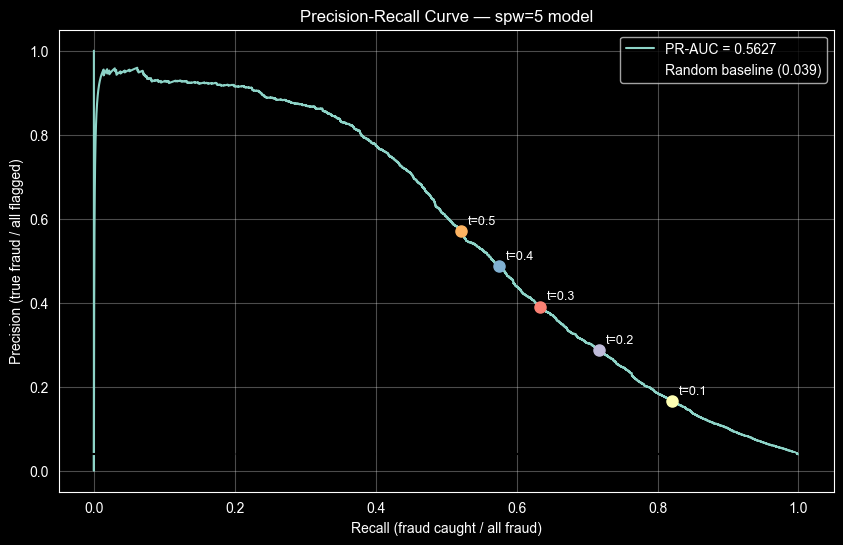

In [67]:
import matplotlib.pyplot as plt
from sklearn.metrics import precision_recall_curve, average_precision_score

precision, recall, thresholds = precision_recall_curve(y_val, y_pred_proba_b)
avg_precision = average_precision_score(y_val, y_pred_proba_b)

plt.figure(figsize=(10, 6))
plt.plot(recall, precision, label=f"PR-AUC = {avg_precision:.4f}")
plt.axhline(y=y_val.mean(), color='k', linestyle='--', label=f"Random baseline ({y_val.mean():.3f})")

# Mark specific thresholds
for t in [0.1, 0.2, 0.3, 0.4, 0.5]:
    idx = (thresholds >= t).argmax()
    plt.plot(recall[idx], precision[idx], 'o', markersize=8)
    plt.annotate(f"t={t}", xy=(recall[idx], precision[idx]),
                 xytext=(5, 5), textcoords='offset points', fontsize=9)

plt.xlabel("Recall (fraud caught / all fraud)")
plt.ylabel("Precision (true fraud / all flagged)")
plt.title("Precision-Recall Curve — spw=5 model")
plt.legend()
plt.grid(alpha=0.3)
plt.show()

### Graphic analysis
Looking at the curve:

- t=0.5 — Precision≈0.60, Recall≈0.55 — conservative, fewer false positives
- t=0.4 — Precision≈0.50, Recall≈0.60 — balanced
- t=0.3 — Precision≈0.39, Recall≈0.68 — higher recall, more false positives

We are going to follow a business decision where we prefer false positives over false negatives. So t=0.3 makes sense. You catch 68% of fraud at the cost of more false alarms. In a real system t=0.3 might mean:
- Above 0.7 → block automatically
- 0.3 to 0.7 → step-up authentication
- Below 0.3 → allow through


In [68]:
threshold = 0.3
y_pred_t = (y_pred_proba_b >= threshold).astype(int)

print(f"Results with threshold={threshold} (spw=5):")
print(classification_report(y_val, y_pred_t))
print(f"ROC-AUC: {roc_auc_score(y_val, y_pred_proba_b):.4f}")  # unchanged — threshold-independent

Results with threshold=0.3 (spw=5):
              precision    recall  f1-score   support

           0       0.98      0.96      0.97    113497
           1       0.39      0.63      0.48      4611

    accuracy                           0.95    118108
   macro avg       0.69      0.80      0.73    118108
weighted avg       0.96      0.95      0.95    118108

ROC-AUC: 0.9035


### Conclusion
 Going from the baseline to spw=5 + t=0.3, we are catching almost twice as many fraud cases (0.39 → 0.68), but for every 10 fraud alerts, only ~4 are real fraud.
 Whether that's acceptable is a business call. In practice, a precision of 0.39 at t=0.3 means a lot of step-up authentications for legitimate customers — annoying but not catastrophic.

### Final evaluation
Run with the test set with a threshold t=0.3

In [69]:
y_pred_test = model_balanced.predict(X_test)
y_pred_proba_test = model_balanced.predict_proba(X_test)[:, 1]
y_pred_test = (y_pred_proba_test >= 0.3).astype(int)
print(classification_report(y_test, y_pred_test))
print(f"ROC-AUC: {roc_auc_score(y_test, y_pred_proba_test):.4f}")

              precision    recall  f1-score   support

           0       0.98      0.96      0.97    114044
           1       0.31      0.56      0.40      4064

    accuracy                           0.94    118108
   macro avg       0.65      0.76      0.69    118108
weighted avg       0.96      0.94      0.95    118108

ROC-AUC: 0.8663


### Final Conclusion
The model performs worse on the test set than on validation. test set covers the most recent 36 days and fraud patterns may have evolved compared to the training period. Maybe the latest transactions are following a different fraud pattern not trained for the training set.
This is precisely why we chose chronological split and it reveals this kind of temporal degradation honestly. A random split would have hidden it.
This finding is important for two reasons:

- Model retraining strategy — confirms that periodic retraining with recent data is necessary. Fraud patterns drift over time.
- ADR validation — our ADR-002 decision to use chronological split is vindicated. We discovered a real problem that random split would have masked.

### Actions to take
1. Retrain with more recent data — include the validation set in training for the final model. We've already evaluated on it, so it's safe to use for training now. Train on train+val, evaluate on test.
2. Sliding window retraining — in production, retrain periodically with the most recent N days of data, dropping older data. Keeps the model current with evolving fraud patterns.

We can apply action 1 now.

In [70]:
X_train_full = pd.concat([X_train, X_val])
y_train_full = pd.concat([y_train, y_val])

model_full = XGBClassifier(random_state=42, scale_pos_weight=5)
model_full.fit(X_train_full, y_train_full)

,"base_score base_score: float | typing.List[float] | NoneThe initial prediction score of all instances, global bias.",None
,booster,None
,"callbacks callbacks: typing.List[xgboost.callback.TrainingCallback] | NoneList of callback functions that are applied at end of each iteration.It is possible to use predefined callbacks by using:ref:`Callback API <callback_api>`... note:: States in callback are not preserved during training, which means callback objects can not be reused for multiple training sessions without reinitialization or deepcopy... code-block:: python for params in parameters_grid: # be sure to (re)initialize the callbacks before each run callbacks = [xgb.callback.LearningRateScheduler(custom_rates)] reg = xgboost.XGBRegressor(**params, callbacks=callbacks) reg.fit(X, y)",None
,colsample_bylevel colsample_bylevel: float | NoneSubsample ratio of columns for each level.,None
,colsample_bynode colsample_bynode: float | NoneSubsample ratio of columns for each split.,None
,colsample_bytree colsample_bytree: float | NoneSubsample ratio of columns when constructing each tree.,None
,"device device: str | None.. versionadded:: 2.0.0Device ordinal, available options are `cpu`, `cuda`, and `gpu`.",None
,"early_stopping_rounds early_stopping_rounds: int | None.. versionadded:: 1.6.0- Activates early stopping. Validation metric needs to improve at least once in every **early_stopping_rounds** round(s) to continue training. Requires at least one item in **eval_set** in :py:meth:`fit`.- If early stopping occurs, the model will have two additional attributes: :py:attr:`best_score` and :py:attr:`best_iteration`. These are used by the :py:meth:`predict` and :py:meth:`apply` methods to determine the optimal number of trees during inference. If users want to access the full model (including trees built after early stopping), they can specify the `iteration_range` in these inference methods. In addition, other utilities like model plotting can also use the entire model.- If you prefer to discard the trees after `best_iteration`, consider using the callback function :py:class:`xgboost.callback.EarlyStopping`.- If there's more than one item in **eval_set**, the last entry will be used for early stopping. If there's more than one metric in **eval_metric**, the last metric will be used for early stopping.",None
,enable_categorical enable_categorical: boolSee the same parameter of :py:class:`DMatrix` for details.,True
,"eval_metric eval_metric: str | typing.List[str | typing.Callable] | typing.Callable | None.. versionadded:: 1.6.0Metric used for monitoring the training result and early stopping. It can be astring or list of strings as names of predefined metric in XGBoost (See:doc:`/parameter`), one of the metrics in :py:mod:`sklearn.metrics`, or anyother user defined metric that looks like `sklearn.metrics`.If custom objective is also provided, then custom metric should implement thecorresponding reverse link function.Unlike the `scoring` parameter commonly used in scikit-learn, when a callableobject is provided, it's assumed to be a cost function and by default XGBoostwill minimize the result during early stopping.For advanced usage on Early stopping like directly choosing to maximize insteadof minimize, see :py:obj:`xgboost.callback.EarlyStopping`.See :doc:`/tutorials/custom_metric_obj` and :ref:`custom-obj-metric` for moreinformation... code-block:: python from sklearn.datasets import load_diabetes from sklearn.metrics import mean_absolute_error X, y = load_diabetes(return_X_y=True) reg = xgb.XGBRegressor( tree_method=""hist"", eval_metric=mean_absolute_error, ) reg.fit(X, y, eval_set=[(X, y)])",None
,feature_types feature_types: typing.Sequence[str] | None.. versionadded:: 1.7.0Used for specifying feature types without constructing a dataframe. Seethe :py:class:`DMatrix` for details.,None


In [71]:
y_pred_test = model_full.predict(X_test)
y_pred_proba_test = model_full.predict_proba(X_test)[:, 1]
y_pred_test = (y_pred_proba_test >= 0.3).astype(int)
print(classification_report(y_test, y_pred_test))
print(f"ROC-AUC: {roc_auc_score(y_test, y_pred_proba_test):.4f}")

              precision    recall  f1-score   support

           0       0.99      0.96      0.97    114044
           1       0.34      0.62      0.44      4064

    accuracy                           0.95    118108
   macro avg       0.66      0.79      0.71    118108
weighted avg       0.96      0.95      0.95    118108

ROC-AUC: 0.9003


### Last conclusion
After running the model with a combined dataset (training + validation) we see a clear improvement

| Metric | Test (train only) | Test (train+val) |
|--------|-------------------|------------------|
| Precision (fraud) | 0.31 | 0.35 |
| Recall (fraud) | 0.55 | 0.62 |
| F1 (fraud) | 0.40 | 0.45 |
| ROC-AUC | 0.8710 | 0.9022 |

All metrics improved. ROC-AUC back to 0.90 and recall up from 55% to 62%.
This confirms the hypothesis — the model needed more recent data to capture evolving fraud patterns.

Before closing the analysis, we are going to see what are the features with the **highest impact in the predictions**.

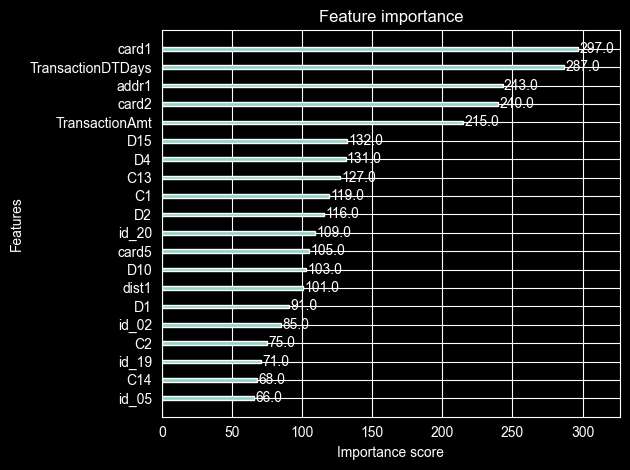

In [72]:
from xgboost import plot_importance

plot_importance(model_full, max_num_features=20)
plt.tight_layout()
plt.show()

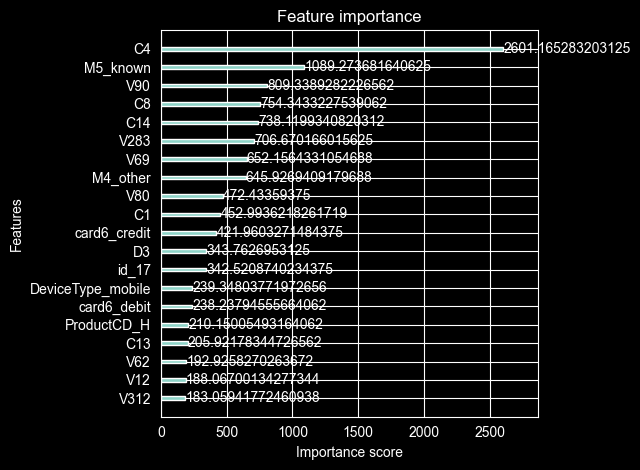

In [73]:
plot_importance(model_full, max_num_features=20, importance_type='gain')
plt.tight_layout()
plt.show()

### Feature Importance Finding — TransactionID
During initial training, TransactionID appeared with high weight importance (246)
but was absent in gain importance. This revealed it as a spurious feature —
a row identifier with no predictive value in production.

**Decision**: TransactionID removed from preprocessing pipeline (see 02_preprocessing.ipynb).
This finding is preserved here for traceability.

In [75]:
# Save
model_full.save_model('../models/model.json')